# Preprocessing: Before vs After Comparison

Load raw DataFrames and processed (Parquet). For each table: summary stats and distribution charts before and after preprocessing.

**Prerequisite:** Run `run_preprocessing.ipynb` so that `artifacts/processed/<table>/` Parquet exists.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import importlib

from src.constants import PROCESSED_DIR
from src.spark.load_data import load_dataset
import src.spark.pandas_sample as _pandas_sample_mod
importlib.reload(_pandas_sample_mod)
to_pandas_sample = _pandas_sample_mod.to_pandas_sample
from src.spark.session import create_spark_session

sns.set_style("whitegrid")
%matplotlib inline

In [2]:
spark = create_spark_session("preprocessing_comparison")

TABLE_NAMES = ["business", "review", "user", "checkin", "tip", "photo"]

raw = {name: load_dataset(spark, name) for name in TABLE_NAMES}

processed = {}
all_exist = all((PROCESSED_DIR / n).exists() for n in TABLE_NAMES)
if all_exist:
    for name in TABLE_NAMES:
        processed[name] = spark.read.parquet(str(PROCESSED_DIR / name))
else:
    print("Some processed paths missing - running preprocess_all (run run_preprocessing.ipynb to write Parquet)")
    from src.preprocessing import preprocess_all
    processed = preprocess_all(spark, load_raw=True)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/29 17:19:42 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/03/29 17:19:42 WARN SparkConf: Note that spark.local.dir will be overridden by the value set by the cluster manager (via SPARK_LOCAL_DIRS in standalone/kubernetes and LOCAL_DIRS in YARN).
26/03/29 17:19:43 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


In [3]:
def numeric_cols_pdf(pdf):
    return pdf.select_dtypes(include=["number"]).columns.tolist()

def plot_distributions(pdf, title, numeric_cols=None, max_cols=6):
    if numeric_cols is None:
        numeric_cols = numeric_cols_pdf(pdf)
    numeric_cols = [c for c in numeric_cols if c in pdf.columns][:max_cols]
    if not numeric_cols:
        return
    n = len(numeric_cols)
    ncols = max(1, (n + 1) // 2)
    nrows = max(1, (n + ncols - 1) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 6))
    # Always a flat list of Axes (handles 1x1 Axes vs ndarray of Axes)
    axes = list(axes.flat) if hasattr(axes, "flat") else [axes]
    for i, col in enumerate(numeric_cols):
        axes[i].hist(pdf[col].dropna(), bins=30, edgecolor="black", alpha=0.7)
        axes[i].set_title(col)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

def plot_boxplots(pdf, title, numeric_cols=None, max_cols=4):
    if numeric_cols is None:
        numeric_cols = numeric_cols_pdf(pdf)
    numeric_cols = [c for c in numeric_cols if c in pdf.columns][:max_cols]
    if not numeric_cols:
        return
    fig, ax = plt.subplots(figsize=(max(6, len(numeric_cols) * 2), 4))
    pdf[numeric_cols].boxplot(ax=ax)
    ax.set_title(title)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

---
## Business

In [4]:
name = "business"
rb, pb = raw[name], processed[name]
print("Before:", rb.count(), "rows", len(rb.columns), "columns")
print("After:", pb.count(), "rows", len(pb.columns), "columns")
print("Before nulls (key):", rb.filter(rb.business_id.isNull()).count())
print("Before duplicates:", rb.count() - rb.dropDuplicates(["business_id"]).count())

Before: 150346 rows 14 columns
After: 150346 rows 54 columns
Before nulls (key): 0


Before duplicates: 0


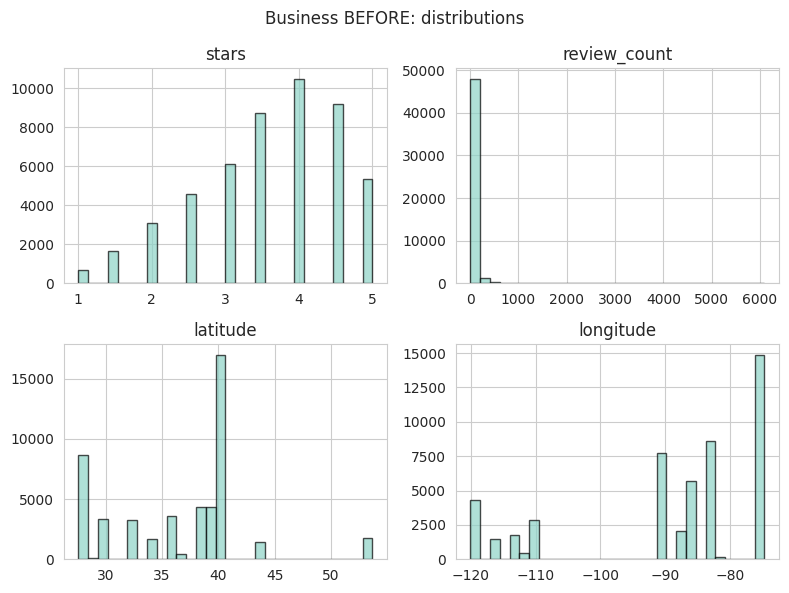

In [5]:
pdf_before = to_pandas_sample(rb, fraction=0.5, columns=["stars", "review_count", "latitude", "longitude"])
nums_before = [c for c in ["stars", "review_count", "latitude", "longitude"] if c in pdf_before.columns]
plot_distributions(pdf_before, "Business BEFORE: distributions", nums_before)

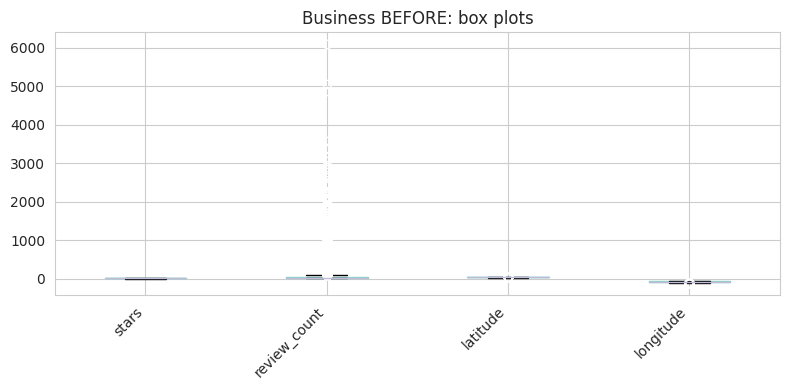

In [6]:
plot_boxplots(pdf_before, "Business BEFORE: box plots", nums_before)

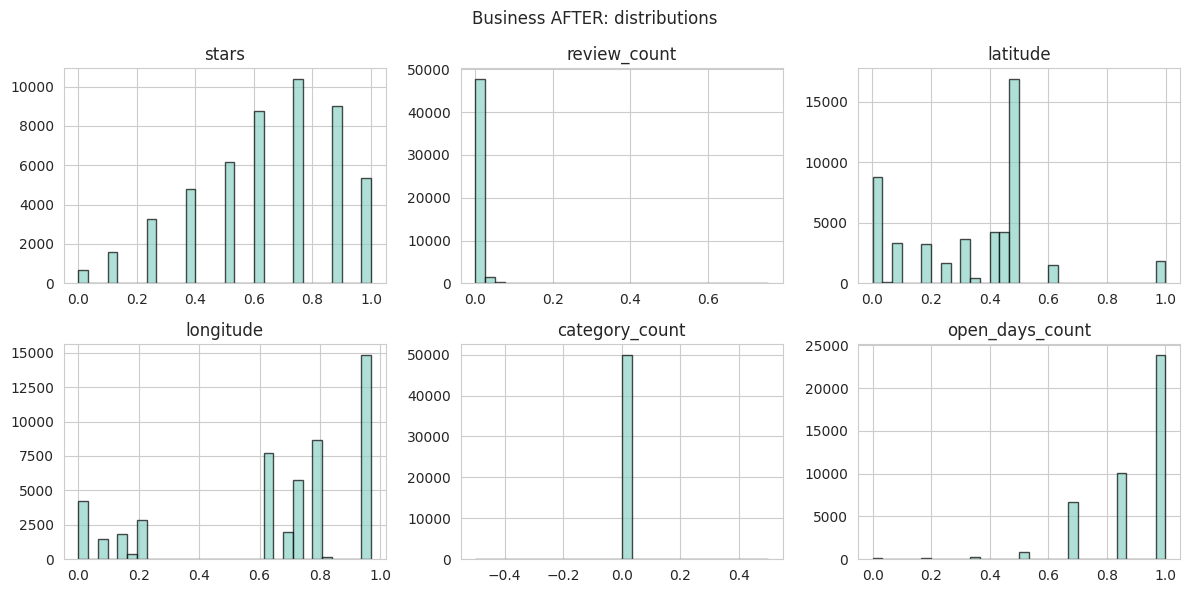

In [7]:
pdf_after = to_pandas_sample(pb, fraction=0.5, columns=["stars", "review_count", "latitude", "longitude", "category_count", "open_days_count"])
nums_after = [c for c in ["stars", "review_count", "latitude", "longitude", "category_count", "open_days_count"] if c in pdf_after.columns]
plot_distributions(pdf_after, "Business AFTER: distributions", nums_after, max_cols=8)

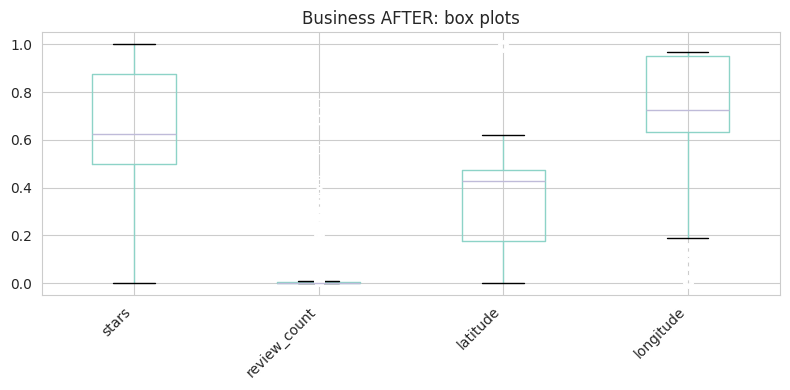

In [8]:
plot_boxplots(pdf_after, "Business AFTER: box plots", nums_after)

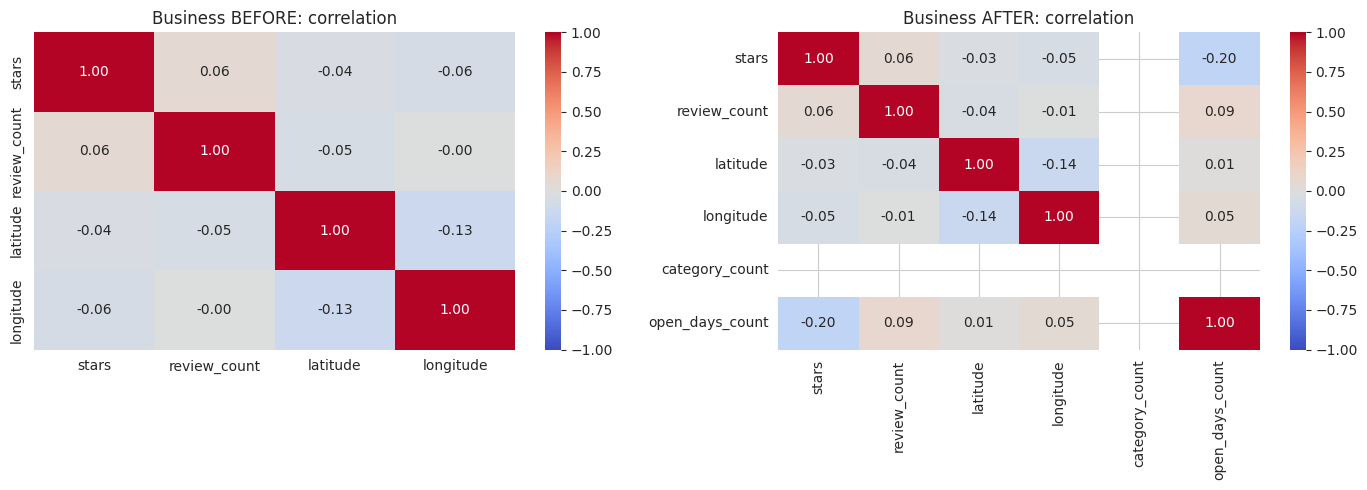

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
num_b = [c for c in nums_before if c in pdf_before.columns]
num_a = [c for c in nums_after if c in pdf_after.columns]
if num_b:
    sns.heatmap(pdf_before[num_b].corr(), annot=True, fmt=".2f", ax=ax1, cmap="coolwarm", vmin=-1, vmax=1)
    ax1.set_title("Business BEFORE: correlation")
if num_a:
    sns.heatmap(pdf_after[num_a].corr(), annot=True, fmt=".2f", ax=ax2, cmap="coolwarm", vmin=-1, vmax=1)
    ax2.set_title("Business AFTER: correlation")
plt.tight_layout()
plt.show()

---
## Review

In [10]:
name = "review"
rr, pr = raw[name], processed[name]
print("Before:", rr.count(), "rows", len(rr.columns), "columns")
print("After:", pr.count(), "rows", len(pr.columns), "columns")
print("Before nulls (review_id):", rr.filter(rr.review_id.isNull()).count())
print("Before duplicates:", rr.count() - rr.dropDuplicates(["review_id"]).count())

Before: 6990280 rows 9 columns
After: 6990280 rows 12 columns


Before nulls (review_id): 0


Before duplicates: 0


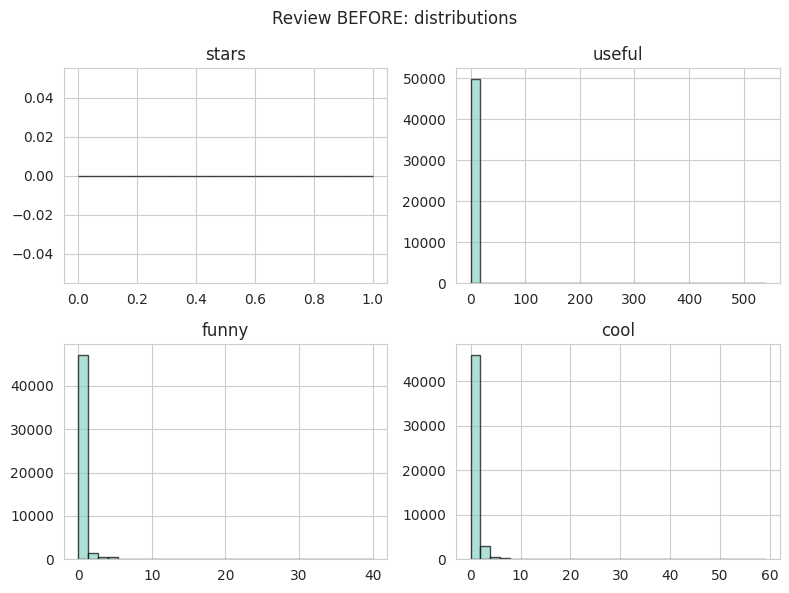

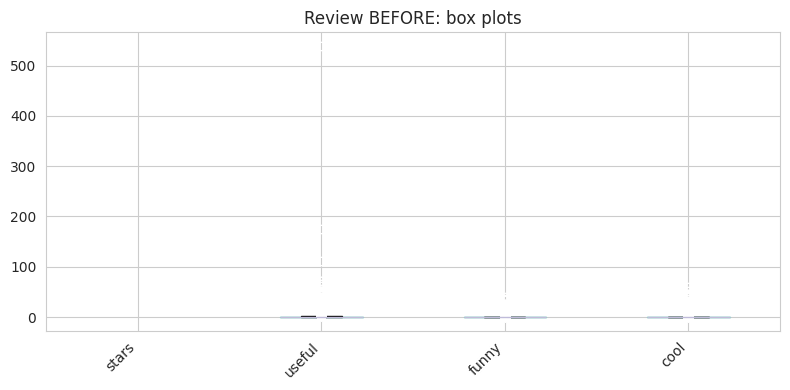

In [11]:
pdf_before = to_pandas_sample(rr, fraction=0.05, columns=["stars", "useful", "funny", "cool"])
nums = [c for c in ["stars", "useful", "funny", "cool"] if c in pdf_before.columns]
plot_distributions(pdf_before, "Review BEFORE: distributions", nums)
plot_boxplots(pdf_before, "Review BEFORE: box plots", nums)

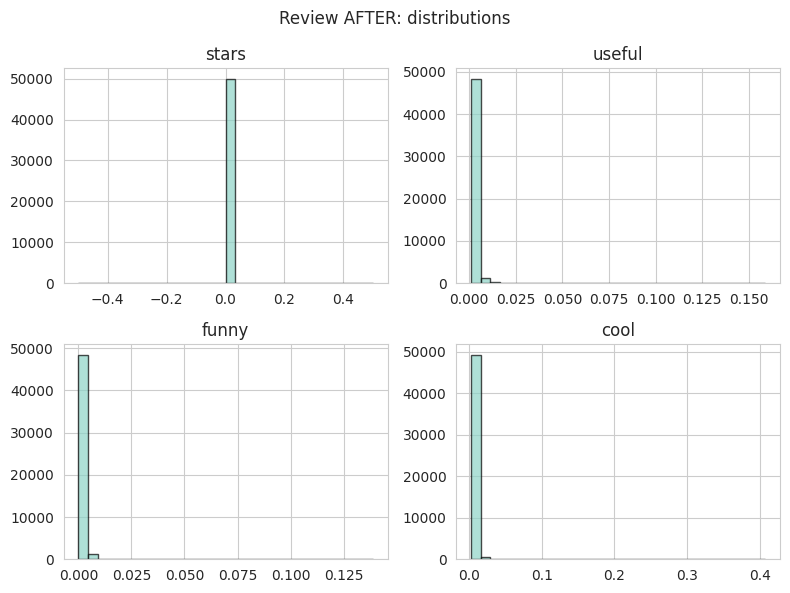

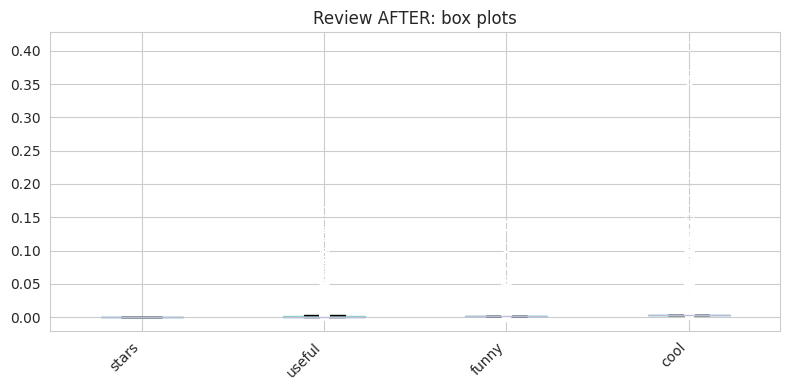

In [12]:
pdf_after = to_pandas_sample(pr, fraction=0.05, columns=["stars", "useful", "funny", "cool"])
nums_a = [c for c in ["stars", "useful", "funny", "cool"] if c in pdf_after.columns]
plot_distributions(pdf_after, "Review AFTER: distributions", nums_a)
plot_boxplots(pdf_after, "Review AFTER: box plots", nums_a)

---
## User

In [13]:
name = "user"
ru, pu = raw[name], processed[name]
print("Before:", ru.count(), "rows", len(ru.columns), "columns")
print("After:", pu.count(), "rows", len(pu.columns), "columns")
print("Before nulls (user_id):", ru.filter(ru.user_id.isNull()).count())
print("Before duplicates:", ru.count() - ru.dropDuplicates(["user_id"]).count())

Before: 1987897 rows 22 columns
After: 1987897 rows 27 columns


Before nulls (user_id): 0


Before duplicates: 0


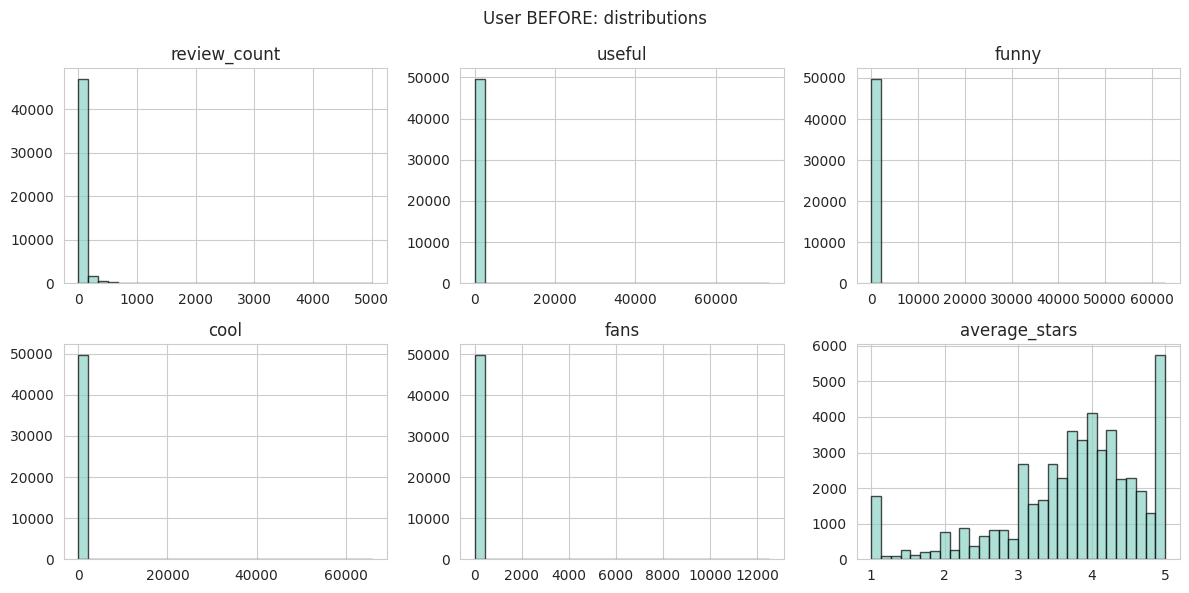

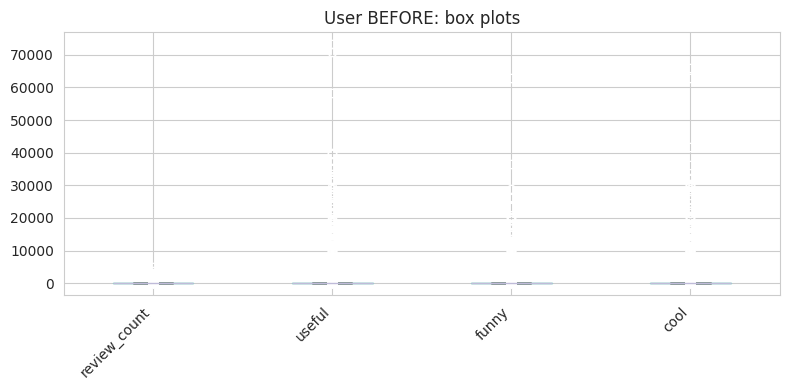

In [14]:
pdf_before = to_pandas_sample(ru, fraction=0.1, columns=["review_count", "useful", "funny", "cool", "fans", "average_stars"])
nums = [c for c in ["review_count", "useful", "funny", "cool", "fans", "average_stars"] if c in pdf_before.columns]
plot_distributions(pdf_before, "User BEFORE: distributions", nums)
plot_boxplots(pdf_before, "User BEFORE: box plots", nums)

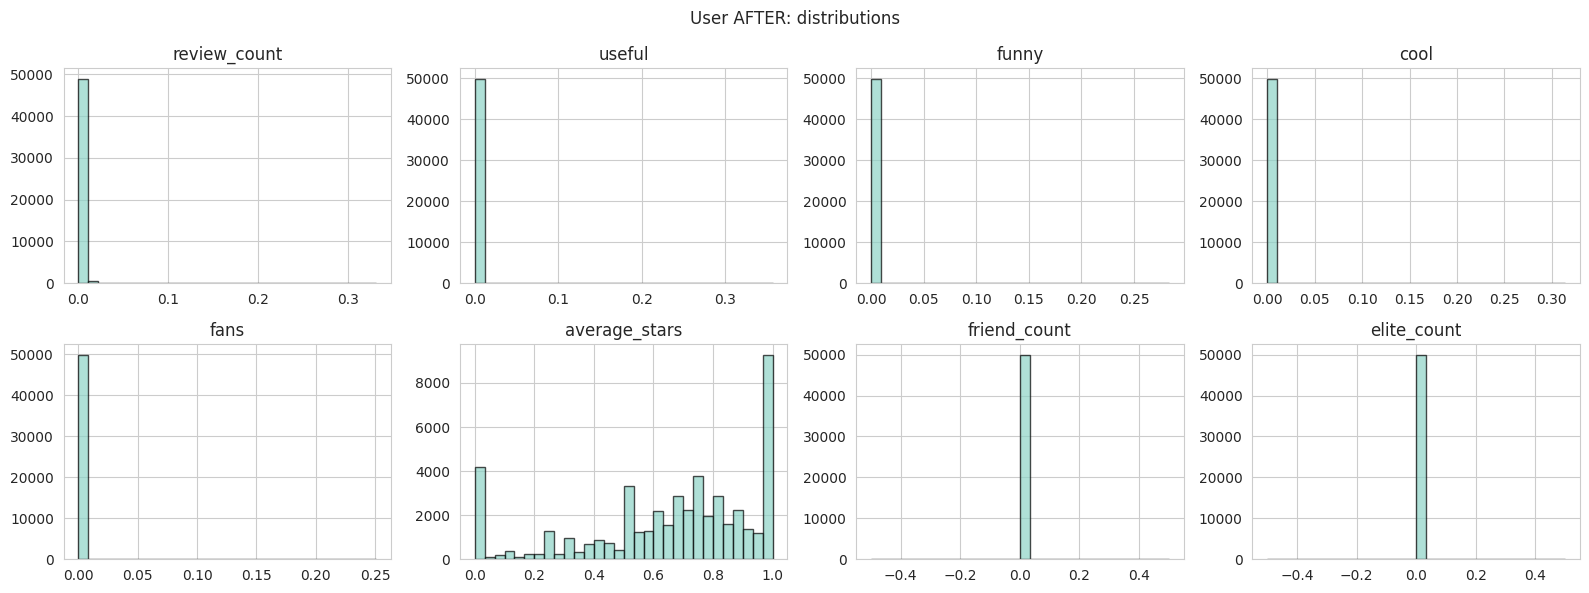

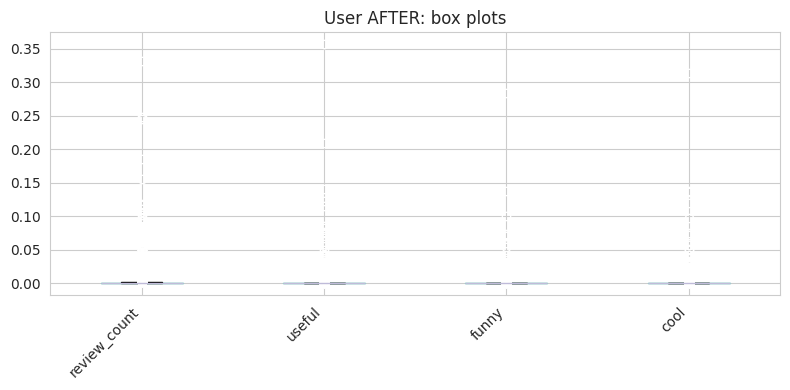

In [15]:
pdf_after = to_pandas_sample(pu, fraction=0.1, columns=["review_count", "useful", "funny", "cool", "fans", "average_stars", "friend_count", "elite_count"])
nums_a = [c for c in ["review_count", "useful", "funny", "cool", "fans", "average_stars", "friend_count", "elite_count"] if c in pdf_after.columns]
plot_distributions(pdf_after, "User AFTER: distributions", nums_a, max_cols=8)
plot_boxplots(pdf_after, "User AFTER: box plots", nums_a)

---
## Checkin

In [16]:
name = "checkin"
rc, pc = raw[name], processed[name]
print("Before:", rc.count(), "rows", len(rc.columns), "columns")
print("After:", pc.count(), "rows", len(pc.columns), "columns")
print("Before nulls (business_id):", rc.filter(rc.business_id.isNull()).count())

Before: 131930 rows 2 columns
After: 131930 rows 6 columns
Before nulls (business_id): 0


In [17]:
pdf_before = to_pandas_sample(rc, fraction=0.3, columns=["business_id", "date"])
print("Before: date column sample:", pdf_before["date"].iloc[0][:80] if "date" in pdf_before.columns and len(pdf_before) else "N/A")

Before: date column sample: 2011-02-15 17:12:00, 2011-07-28 02:46:10, 2012-03-11 10:30:02, 2012-04-24 07:07:


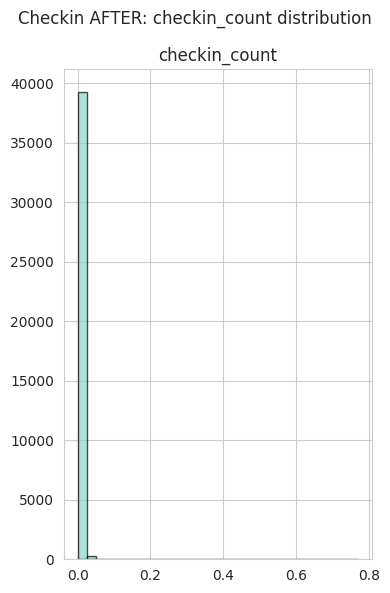

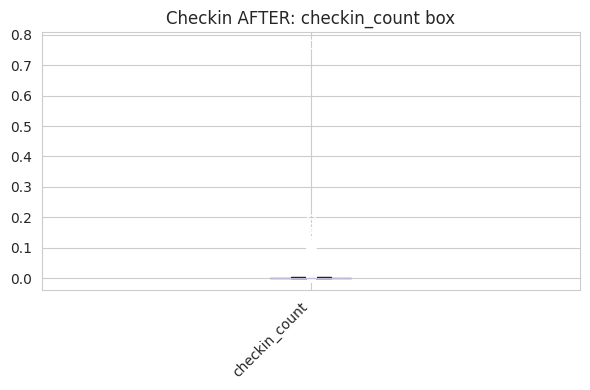

In [18]:
pdf_after = to_pandas_sample(pc, fraction=0.3, columns=["checkin_count"])
nums = [c for c in ["checkin_count"] if c in pdf_after.columns]
if nums:
    plot_distributions(pdf_after, "Checkin AFTER: checkin_count distribution", nums)
    plot_boxplots(pdf_after, "Checkin AFTER: checkin_count box", nums)

---
## Tip

In [19]:
name = "tip"
rt, pt = raw[name], processed[name]
print("Before:", rt.count(), "rows", len(rt.columns), "columns")
print("After:", pt.count(), "rows", len(pt.columns), "columns")
print("Before nulls (user_id/business_id):", rt.filter(rt.user_id.isNull() | rt.business_id.isNull()).count())

Before: 908915 rows 5 columns
After: 908836 rows 8 columns
Before nulls (user_id/business_id): 0


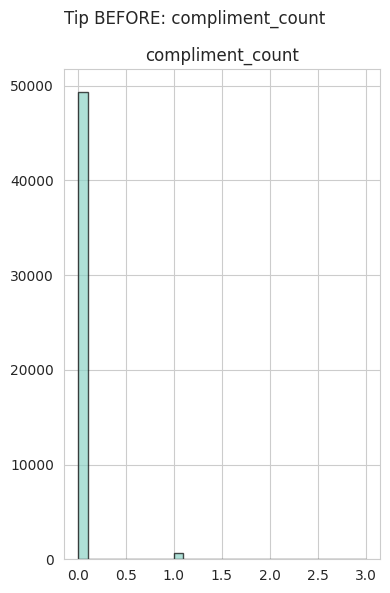

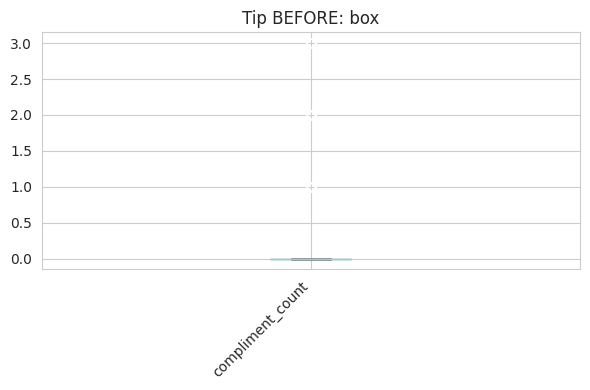

In [20]:
pdf_before = to_pandas_sample(rt, fraction=0.1, columns=["compliment_count"])
nums = [c for c in ["compliment_count"] if c in pdf_before.columns]
plot_distributions(pdf_before, "Tip BEFORE: compliment_count", nums)
plot_boxplots(pdf_before, "Tip BEFORE: box", nums)

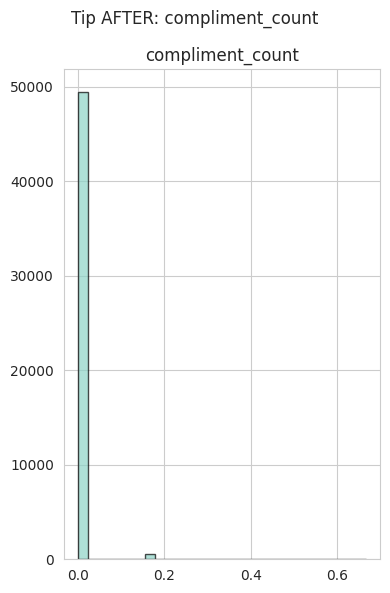

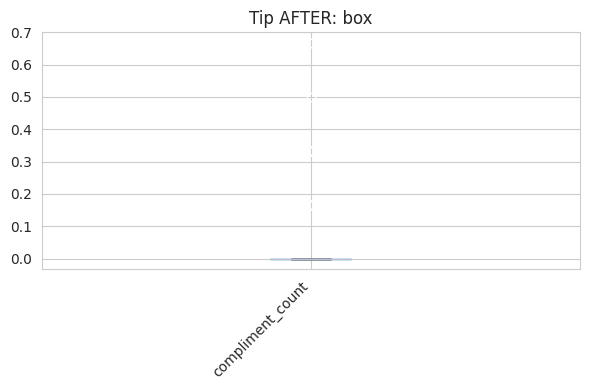

In [21]:
pdf_after = to_pandas_sample(pt, fraction=0.1, columns=["compliment_count"])
nums_a = [c for c in ["compliment_count"] if c in pdf_after.columns]
plot_distributions(pdf_after, "Tip AFTER: compliment_count", nums_a)
plot_boxplots(pdf_after, "Tip AFTER: box", nums_a)

---
## Photo

In [22]:
name = "photo"
rph, pph = raw[name], processed[name]
print("Before:", rph.count(), "rows", len(rph.columns), "columns")
print("After:", pph.count(), "rows", len(pph.columns), "columns")
print("Before nulls (photo_id):", rph.filter(rph.photo_id.isNull()).count())
print("Before duplicates:", rph.count() - rph.dropDuplicates(["photo_id"]).count())

Before: 200100 rows 4 columns
After: 200098 rows 4 columns
Before nulls (photo_id): 0
Before duplicates: 2


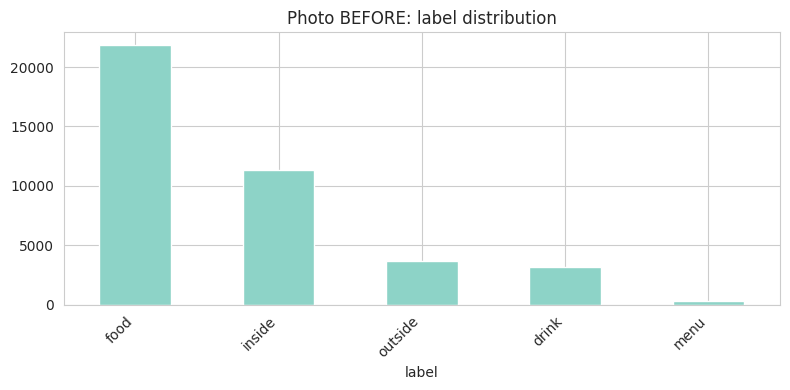

In [23]:
pdf_before = to_pandas_sample(rph, fraction=0.2, columns=["label"])
if "label" in pdf_before.columns:
    fig, ax = plt.subplots(figsize=(8, 4))
    pdf_before["label"].value_counts().head(15).plot(kind="bar", ax=ax)
    ax.set_title("Photo BEFORE: label distribution")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

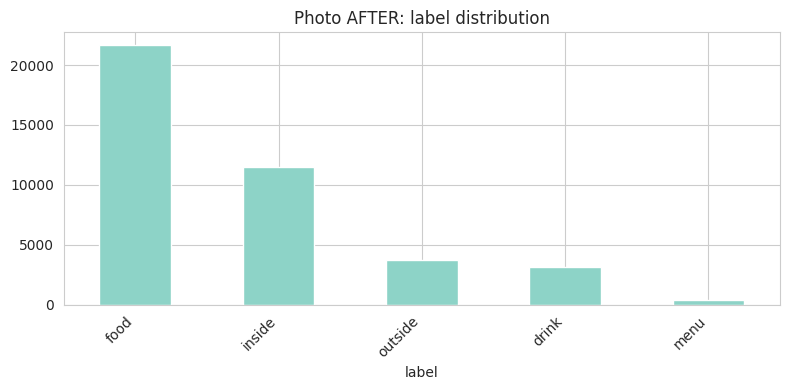

In [24]:
pdf_after = to_pandas_sample(pph, fraction=0.2, columns=["label"])
if "label" in pdf_after.columns:
    fig, ax = plt.subplots(figsize=(8, 4))
    pdf_after["label"].value_counts().head(15).plot(kind="bar", ax=ax)
    ax.set_title("Photo AFTER: label distribution")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

In [25]:
print("Comparison complete. Summary:")
for name in TABLE_NAMES:
    if name in raw and name in processed:
        r, p = raw[name].count(), processed[name].count()
        cr, cp = len(raw[name].columns), len(processed[name].columns)
        print(f"  {name}: rows {r} -> {p}, columns {cr} -> {cp}")

Comparison complete. Summary:
  business: rows 150346 -> 150346, columns 14 -> 54


  review: rows 6990280 -> 6990280, columns 9 -> 12


  user: rows 1987897 -> 1987897, columns 22 -> 27
  checkin: rows 131930 -> 131930, columns 2 -> 6


  tip: rows 908915 -> 908836, columns 5 -> 8
  photo: rows 200100 -> 200098, columns 4 -> 4
